# Tidsinhomogene modeller

I Notebook 01–02 antog jeg at populationsstørrelsen er konstant over tid. Formålet med denne notebook, er at jeg introducerer tidsinhomogene modeller, hvor coalescence raten (og dermed den effektive populationsstørrelse $N_e$) ændrer sig over tid. Disse er nødvendige for at rekonstruere bavianernes historie. I denne notebook, vil jeg derfor komme ind på følgende:

1. **Epochs og step-wise populationsstørrelsesændringer** — den grundlæggende model
2. **Bottleneck-effekten på CDF** — hvordan et historisk fald i $N_e$ aftegner sig i data
3. **Marginal grenvarighed over tid** — hvornår bidrog de forskellige lineage-typer.
4. **SFS under skiftende populationsstørrelser** — forbindelsen til Notebook 03's observerede SFS
5. **Sammenligning med Pool & Nielsen** — validering mod analytiske resultater.

In [1]:
# Importer nødvendige pakker
from phasic import (
    Graph, with_ipv,
    StateIndexer, Property
)
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import seaborn as sns
%config InlineBackend.figure_format = 'svg'
from functools import partial
from itertools import combinations_with_replacement
from vscodenb import set_vscode_theme, vscode_theme

all_pairs = partial(combinations_with_replacement, r=2)
np.random.seed(42)
set_vscode_theme()
sns.set_palette('tab10')

## 1. Bottleneck: tidsinhomogen CDF

Bottleneck er en periode med kraftigt reduceret populationsstørrelse fx pga. klimaforandringer, sygdomme eller geografisk isolation. Under bottleneck er coalescence raten meget høj (mange par samles hurtigt), og man ser en karakteristisk "trin" i CDF'en.

Jeg modellerer dette ved at opdatere modelparametrene undervejs i beregningen via en *distribution_context*. Parametrene skifter ved faste tidspunkter svarende til epoch-grænser.

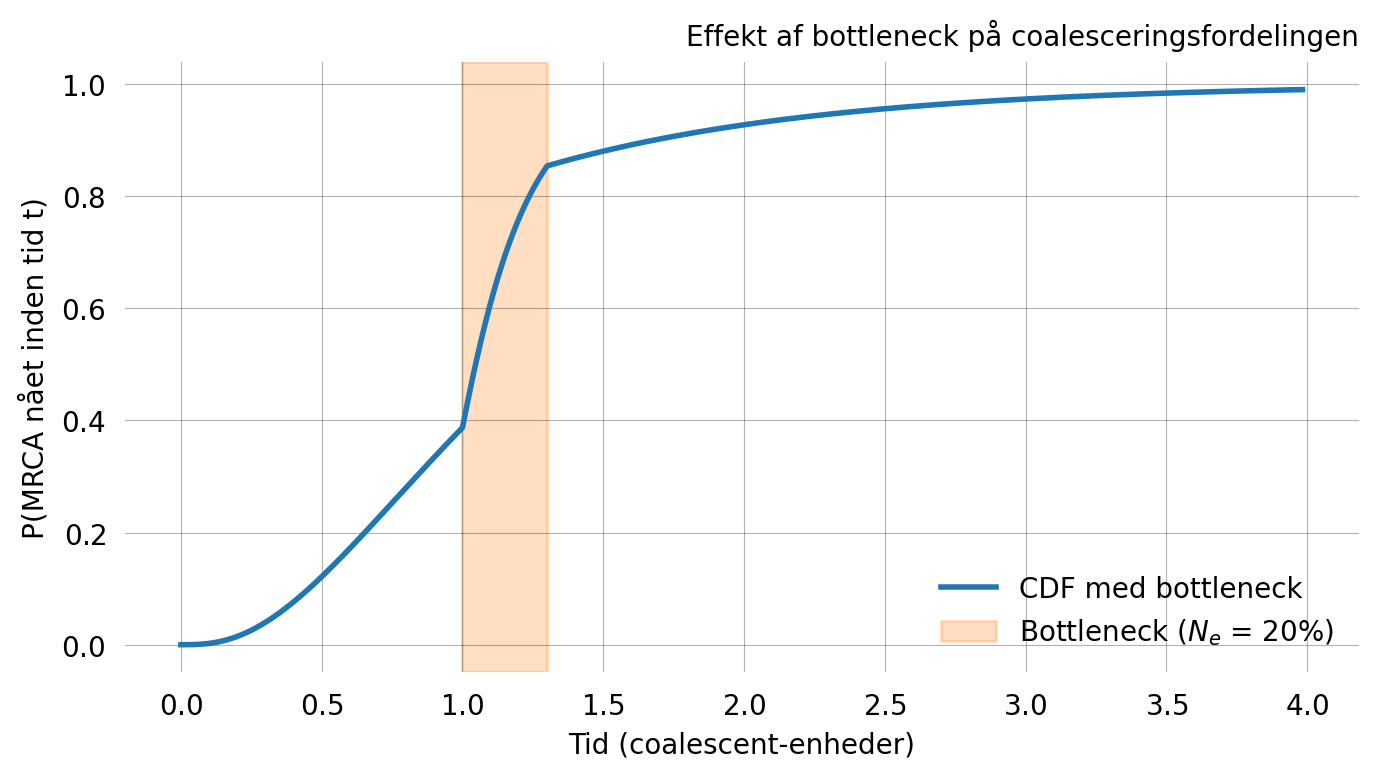

CDF accelererer inde i bottlenecket (stejl stigning) fordi
coalescence-raten er høj ved lille N_e. Dette er et karakteristisk signal.


In [2]:
# Bygger standard coalescent med 4 prøver (genbrugt fra Notebook 01)
nr_samples = 4

@with_ipv([nr_samples] + [0] * (nr_samples - 1))
def coalescent_1param(state):
    transitions = []
    for i in range(state.size):
        for j in range(i, state.size):
            same = int(i == j)
            if same and state[i] < 2: continue
            if not same and (state[i] < 1 or state[j] < 1): continue
            new = state.copy()
            new[i] -= 1
            new[j] -= 1
            new[i + j + 1] += 1
            transitions.append([new, [state[i] * (state[j] - same) / (1 + same)]])
    return transitions

# Bottleneck-parametre
N = 1
N_bottle = 0.2
t_start, t_end = 1.0, 1.3

param_changes = [
    (t_start, [1/N_bottle]),   # Bottleneck starter
    (t_end,   [1/N])           # Bottleneck slutter
]

graph = Graph(coalescent_1param)
graph.update_weights([1/N])

# Beregn CDF step-by-step med skiftende parametre
cdf_cutoff = 0.99
cdf_vals, times = [], []
ctx = graph.distribution_context()

for change_time, new_params in param_changes:
    while ctx.time() < change_time:
        cdf_vals.append(ctx.cdf())
        times.append(ctx.time())
        ctx.step()
        if ctx.cdf() >= cdf_cutoff:
            break
    graph.update_weights(new_params)

while ctx.cdf() < cdf_cutoff:
    cdf_vals.append(ctx.cdf())
    times.append(ctx.time())
    ctx.step()

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(times, cdf_vals, color='C0', lw=2, label='CDF med bottleneck')
ax.axvspan(xmin=t_start, xmax=t_end, alpha=0.25, color='C1', label=f'Bottleneck ($N_e$ = {N_bottle*100:.0f}%)')
ax.set_xlabel("Tid (coalescent-enheder)")
ax.set_ylabel("P(MRCA nået inden tid t)")
ax.set_title("Effekt af bottleneck på coalesceringsfordelingen")
ax.legend()
plt.tight_layout()
plt.show()

print("CDF accelererer inde i bottlenecket (stejl stigning) fordi")
print("coalescence-raten er høj ved lille N_e. Dette er et karakteristisk signal.")

## 2. Epoch-baserede modeller med *add_epoch*

For mere realistiske rekonstruktioner fx som de bruges i PSMC eller SMC++ har jeg brug for mange epoches, hver med sin egen $N_e$. Phasic implementerer dette ved at udvide grafen for hver epoch: nye state tilføjes, og overgange imellem epoches beregnes fra *accumulated_occupancy* i den foregående epoch. Staten indeholder nu også en epoch-label, der fortæller hvilken epoch processen befinder sig i. Dette muliggør korrekte transitions.

In [6]:
def coalescent_epoch(state, epochs=None, epoch_idx=None, indexer=None):
    """
    Coalescent-model der er bevidst om epochs.
    Returnerer kun transitions for state i den aktuelle epoch.
    """
    transitions = []
    epoch_idx = int(epoch_idx)

    # Ignorer state fra andre epoches
    if state[indexer.epoch] != epoch_idx:
        return transitions

    for i, j in all_pairs(indexer.lineages):
        pi = indexer.lineages.index_to_props(i)
        pj = indexer.lineages.index_to_props(j)

        if state.sum() <= 1:
            continue
        same = int(pi.ton == pj.ton)
        if same and state[i] < 2: continue
        if not same and (state[i] < 1 or state[j] < 1): continue

        new = state.copy()
        new[i] -= 1
        new[j] -= 1
        k = indexer.props_to_index(ton=pi.ton + pj.ton)
        new[k] += 1

        # Rate-koefficient: kun aktiv i den aktuelle epoch
        coeff = np.zeros(len(epochs) + 1)
        coeff[epoch_idx] = state[i] * (state[j] - same) / (1 + same)
        transitions.append([new, coeff])

    return transitions


def add_epoch(graph, callback, epochs, epoch_idx, indexer):
    """
    Udvid grafen med en ny epoch.
    Beregner overgangsrater fra den foregående epoch vha. stop-sandsynligheder.
    """
    epoch = epochs[epoch_idx]
    stop_probs   = np.array(graph.stop_probability(epoch))
    accum_v_time = np.array(graph.accumulated_occupancy(epoch))

    with np.errstate(invalid='ignore'):
        epoch_trans_rates = stop_probs / accum_v_time

    for i in range(1, graph.vertices_length() - 1):
        if epoch_trans_rates is None or np.isnan(epoch_trans_rates[i]):
            continue
        if graph.vertex_at(i).edges_length() == 0:
            continue

        vertex = graph.vertex_at(i)
        state  = vertex.state()

        if state[indexer.epoch] != epoch_idx - 1:
            continue

        # Lav søster state i den nye epoch
        sister_state = state.copy()
        sister_state[indexer.epoch] = epoch_idx
        child = graph.find_or_create_vertex(sister_state)

        coeff = np.zeros(len(epochs) + 1)
        coeff[-1] = epoch_trans_rates[i]
        vertex.add_edge(child, coeff)

    graph.extend(callback, epochs=epochs, epoch_idx=epoch_idx, indexer=indexer)


print("Epoch-funktioner defineret.")

Epoch-funktioner defineret.


Model med 3 epoches og 10 prøver
Populationsstørrelser: [(0, 1), (1, 5), (2, 10)]

De første 5 momenter: ['8.73', '173.42', '5233.84', '209923.90', '10506328.51']


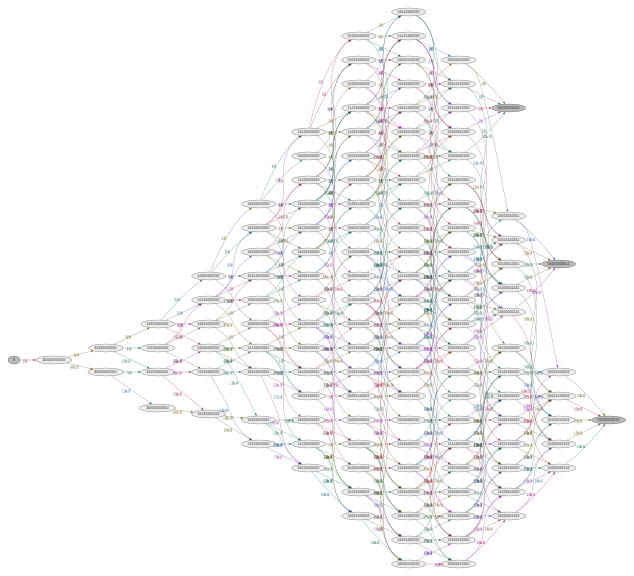

In [7]:
# Byg en model med 3 epoches og skiftende populationsstørrelser
# epochs = tidspunkter for epoch-skift (i coalescent-enheder)
# pop_sizes = N_e i hver epoch (relativ skala)

nr_samples = 10
epochs     = [0, 1, 2]
pop_sizes  = [1, 5, 10]   # Voksende population bagud i tid

indexer = StateIndexer(
    lineages=[Property('ton', min_value=1, max_value=nr_samples)],
    slots=['epoch']
)

ipv = [0] * indexer.state_length
ipv[indexer.props_to_index(ton=1)] = nr_samples

# Byg grafen for epoch 0
graph = Graph(
    coalescent_epoch,
    ipv=ipv,
    epochs=epochs,
    epoch_idx=0,
    indexer=indexer,
)
graph.update_weights([1/size for size in pop_sizes] + [1])

# Tilføj de resterende epoches
for epoch_idx in range(1, len(epochs)):
    graph.update_weights([1/size for size in pop_sizes] + [1])
    add_epoch(graph, coalescent_epoch, epochs, epoch_idx, indexer)

graph.update_weights([1/size for size in pop_sizes] + [1])

print(f"Model med {len(epochs)} epoches og {nr_samples} prøver")
print(f"Populationsstørrelser: {list(zip(epochs, pop_sizes))}")
print()
print(f"De første 5 momenter: {[f'{m:.2f}' for m in graph.moments(5)]}")

graph.plot(size=(12, 8), wrap=False, max_nodes=300)

## 3. SFS under tidsinhomogen model

Det forventede SFS ændrer sig, når man tillader populationsstørrelses ændringer. Her beregner jeg det teoretiske SFS for 3-epoch modellen og sammenligner med den neutrale forventning.

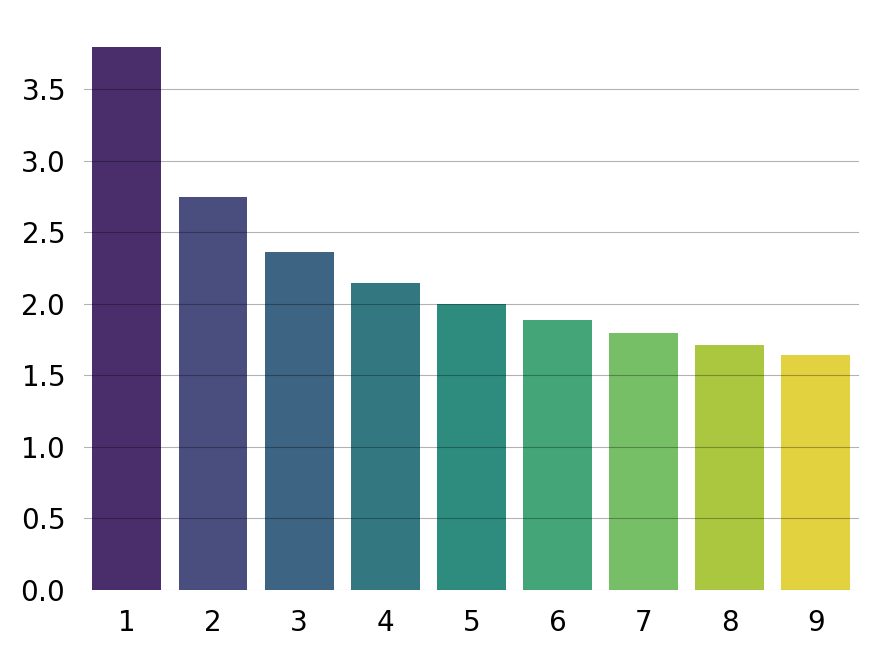

In [9]:
# Beregn SFS for 3-epoch modellen via reward-transforms
# Get states and remove epoch label column
state_mat = graph.states()
rewards   = state_mat[:, :-1]   # Fjern epoch-label

x = np.arange(1, nr_samples)
sfs_epoch = np.zeros(nr_samples - 1)

for i in range(nr_samples - 1):
    reward_vec = rewards[:, i]
    transformed = graph.reward_transform(reward_vec)
    sfs_epoch[i] = transformed.moments(1)[0]

sns.barplot(x=x, y=sfs_epoch, hue=x, width=0.8, palette='iridis', legend=False);


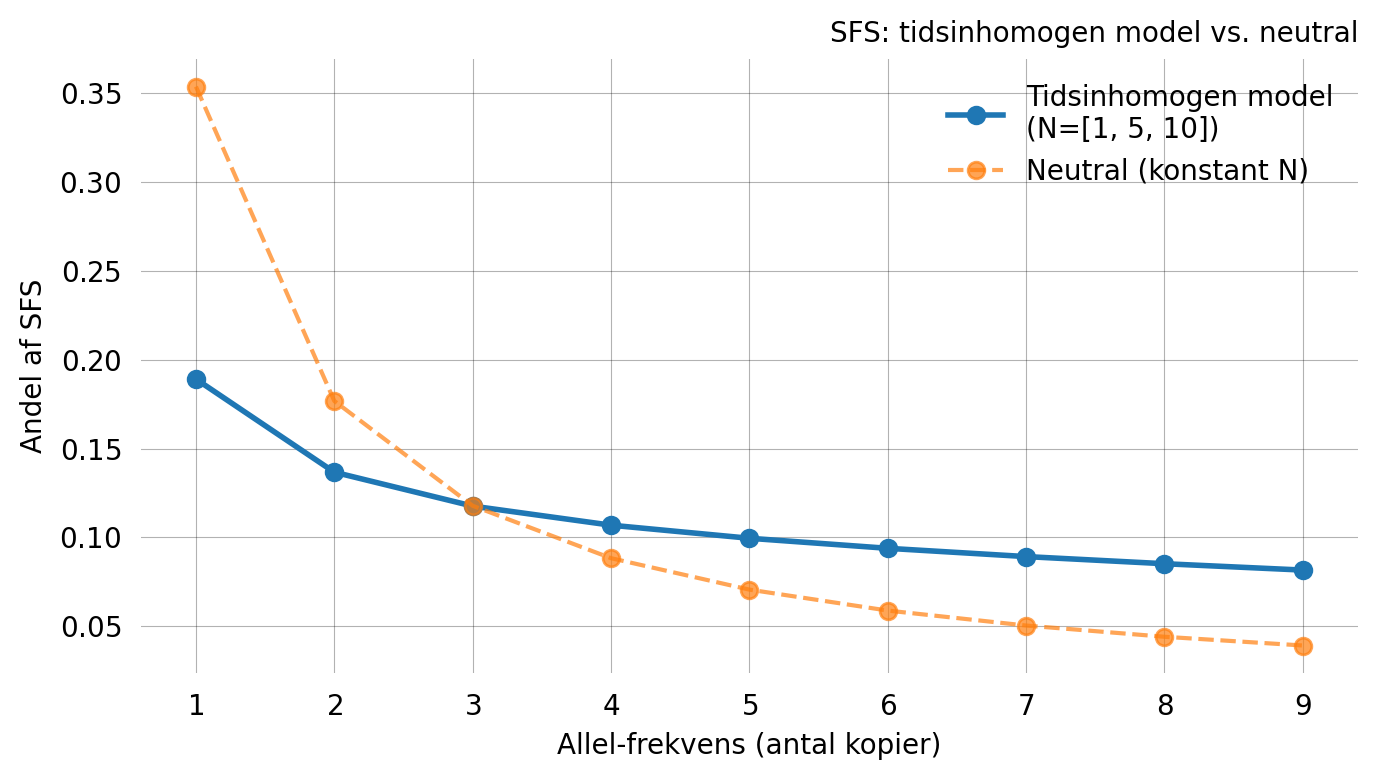

Populationsvækst bagud i tid (N: 1 → 5 → 10) producerer
proportionelt flere singletons — et klassisk signal fra en voksende population.


In [10]:
# Sammenlign med neutral forventning (1/k)
neutral = 1.0 / x
neutral = neutral / neutral.sum()
sfs_epoch_norm = sfs_epoch / sfs_epoch.sum()

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, sfs_epoch_norm, 'o-', label=f'Tidsinhomogen model\n(N={pop_sizes})', color='C0', lw=2)
ax.plot(x, neutral, 'o--', label='Neutral (konstant N)', color='C1', lw=1.5, alpha=0.7)
ax.set_xlabel("Allel-frekvens (antal kopier)")
ax.set_ylabel("Andel af SFS")
ax.set_title("SFS: tidsinhomogen model vs. neutral")
ax.legend()
plt.tight_layout()
plt.show()


print("Populationsvækst bagud i tid (N: 1 → 5 → 10) producerer")
print("proportionelt flere singletons — et klassisk signal fra en voksende population.")

## 4. Marginal grenvarighed over tid

Jeg kan visualisere, hvornår de forskellige lineage-typer bidrog til genetisk diversitet. Dette heatmap viser, for en given tid $t$, hvilken andel af den akkumulerede grenvarighed der stammer fra singletons, doubletons, etc.

Hvis singletoner dominerer tidligt og doubletons dominerer sent, afspejler det en demografisk ændring, en stor gammel population (mange doubleter) efterfulgt af en nyere ekspansion (mange singletons).

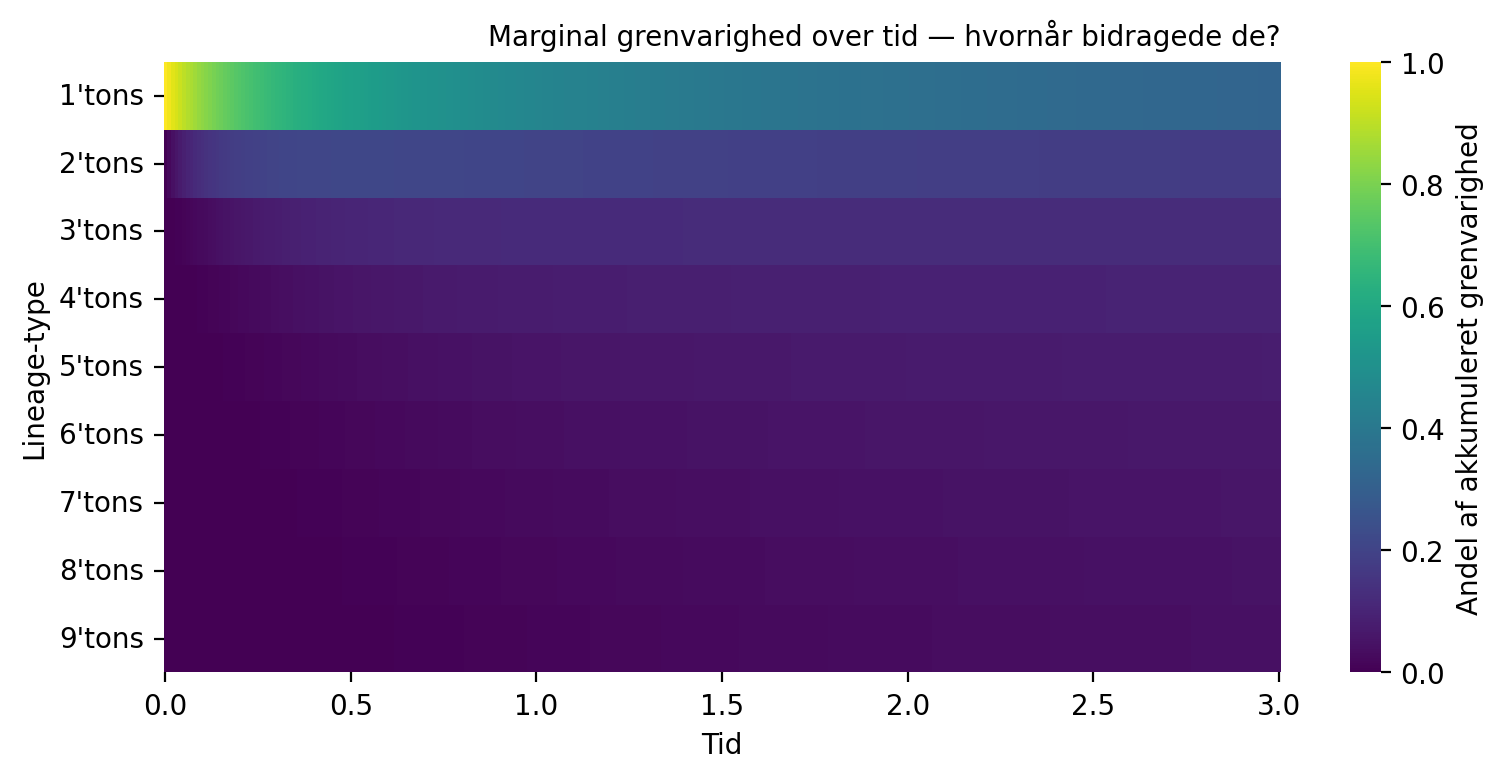

<Figure size 500x370 with 0 Axes>

In [11]:
@np.vectorize
def brlen_accumulated(i, t):
    """Akkumuleret grenvarighed for lineage-type i op til tid t."""
    acc_occ = graph.accumulated_occupancy(t) * rewards[:, i]
    return np.sum(acc_occ).item()

times    = np.linspace(0, 3, 301)
tons     = list(range(nr_samples - 1))
X, Y     = np.meshgrid(tons, times, indexing='ij')
result   = brlen_accumulated(X, Y)

# Normaliser per tidspunkt
col_sums = result.sum(axis=0)
result   = result / col_sums[np.newaxis, :]

df_heatmap = pd.DataFrame(
    result,
    columns=np.round(times, 3),
    index=[f"{i+1}'tons" for i in range(nr_samples - 1)]
)

with vscode_theme(style='ticks'):
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.heatmap(df_heatmap, cmap='viridis', ax=ax,
                xticklabels=50,
                cbar_kws={'label': 'Andel af akkumuleret grenvarighed'})
    ax.set_xlabel('Tid')
    ax.set_ylabel('Lineage-type')
    ax.set_title('Marginal grenvarighed over tid — hvornår bidragede de?')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

## 5. Validering: sammenligning med Pool & Nielsen

Jeg validerer epoch-modellen mod analytiske resultater fra Pool & Nielsen (2007), der gav lukkede formler for forventet coalesceringstid i en piecewise-constant demografisk model. En god match bekræfter, at vores implementering er korrekt.

In [12]:
def exp_coal(g, N):
    """Forventet coalesceringstid inden for en epoch (haploid N)."""
    # return 2*N - (g * np.exp(-g/(2*N))) / (1 - np.exp(-g/(2*N)))
    return N - (g * np.exp(-g/(N))) / (1 - np.exp(-g/(N)))

def epoch(demog, h, i):
    """Rekursiv beregning af forventet coalesceringstid på tværs af epoches."""
    g, N = demog[i]
    N *= h
    if i == len(demog)-1:
    #     return 2*N
    # return (1-np.exp(-g/(2*N))) * exp_coal(g, N) + np.exp(-g/(2*N)) * (g + epoch(demog, h, i+1))
        return N
    return (1-np.exp(-g/(N))) * exp_coal(g, N) + np.exp(-g/(N)) * (g + epoch(demog, h, i+1))

def pool_nielsen(gens, Ne, h):
    """ Pool & Nielsen forventet coalesceringstid. h=1 for autosomalt, 0.75 for chrX."""
    epochs = list()
    for i in range(len(gens)):
        if i == 0:
            epochs.append((gens[i+1], Ne[i]))
        elif i == len(gens)-1:
            epochs.append((None, Ne[i]))    
        else:
            epochs.append((gens[i+1] - gens[i], Ne[i]))
    return epoch(epochs, h, 0)


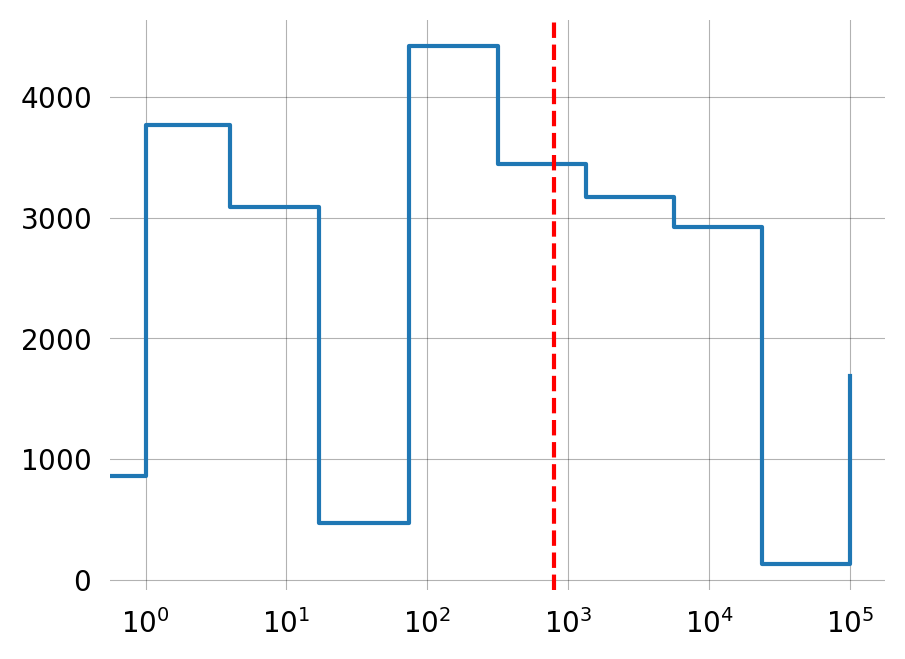

In [13]:
n = 10
sampledemog_data = pd.DataFrame(dict(years=[0]+np.logspace(0, 5, n-1, dtype=int, base=10).tolist(),
                               Ne=np.random.randint(1, 5_000, size=n),
                               population=['pop']*n
                              ))

sampledemog_data.sort_values('years', inplace=True)

gen_time = 30
exp_coal_time = pool_nielsen(gens=sampledemog_data.years / gen_time, 
                               Ne=sampledemog_data.Ne,
                               h=1)
# pool_nielsen(gens, Ne, 0.75)
plt.step(sampledemog_data.years, sampledemog_data.Ne, where='post')
plt.gca().set_xscale('log')
plt.gca().axvline(exp_coal_time, color='red', linestyle='--')
plt.show()